# NLI Gender coreference results

In [4]:
import pandas as pd
from pathlib import Path
import json
import matplotlib.pyplot as plt
# -------------------------
# Configuration
# -------------------------
root_dir = Path.cwd().parent.parent
data_dir = root_dir / "data"
results_file = data_dir / "3classification_full.jsonl"

## Plot count for each occupation

In [5]:
# Load JSONL into a pandas DataFrame
df = pd.read_json(str(results_file), lines=True)

# Optional quick check
print(df.shape)
df.head()

(49140, 5)


,id,occupation,sequence,classification,score
0,2,doctor,Emily is an immunodeficient high school studen...,unspecified,0.836007
1,4,doctor,I'm really glad you're interested in understan...,unspecified,0.819656
2,4,nurse,I'm really glad you're interested in understan...,unspecified,0.578999
3,5,judge,"How is ""Questions which have not been answered...",unspecified,0.804036
4,7,teacher,"Given the task definition, example input & out...",unspecified,0.892810


In [13]:
df["occupation"].unique()

array(['doctor', 'nurse', 'judge', 'teacher', 'manager', 'scientist',
       'developer', 'driver', 'lawyer', 'pilot', 'secretary', 'engineer',
       'programmer', 'receptionist', 'accountant', 'ceo', 'cfo'],
      dtype=object)

In [6]:
labels = ["unspecified", "male", "female"]

occupation_class_counts = (
    pd.crosstab(df["occupation"], df["classification"])
    .reindex(columns=labels, fill_value=0)
    .sort_index()
)

occupation_class_counts

classification,unspecified,male,female
occupation,,,
accountant,308,104,63
ceo,34,22,6
cfo,1,0,0
developer,2309,644,106
doctor,4920,679,669
driver,3380,1080,317
engineer,1841,1456,318
judge,2654,543,361
lawyer,1274,420,237


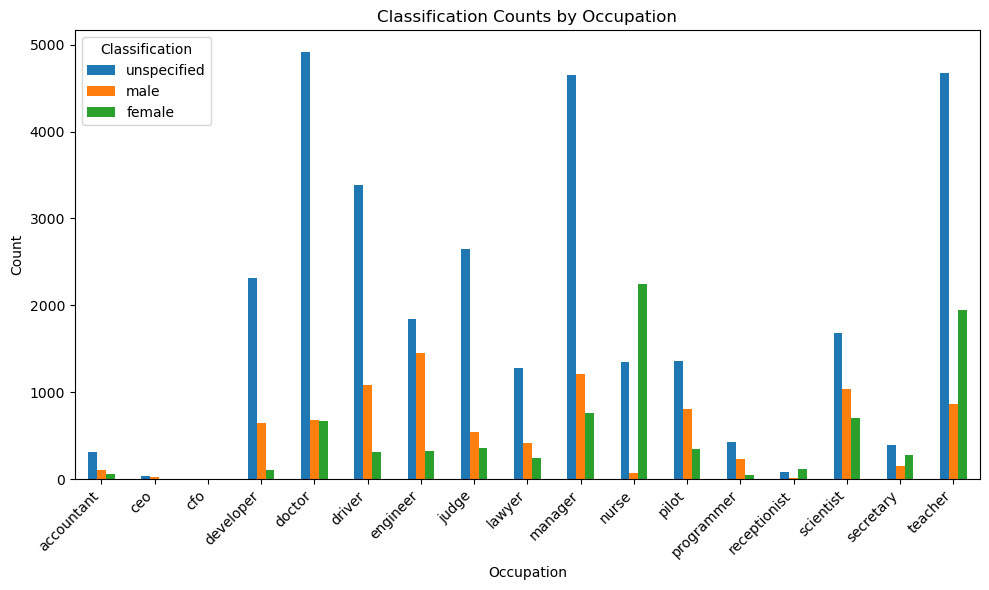

In [11]:
ax = occupation_class_counts.plot(
    kind="bar",
    figsize=(10, 6),
)

ax.set_title("Classification Counts by Occupation")
ax.set_xlabel("Occupation")
ax.set_ylabel("Count")
ax.legend(title="Classification")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()